# Finite Size Scaling — Modelo de Ising 2D

Análisis de escalado de tamaño finito (FSS) para el modelo de Ising 2D simulado con tres algoritmos: **Metropolis**, **Glauber** y **Wolff**.

Se determinan:
- La temperatura crítica $T_c$ mediante el cruce del cumulante de Binder $U_4$.
- Los exponentes críticos $\nu$, $\beta/\nu$ y $\gamma/\nu$ mediante ajustes log-log.
- El colapso de datos como verificación del escalado.

## 1. Importaciones y carga de datos

Leemos los ficheros de simulación. Cada uno tiene columnas: `L, T, e, m, Cv, m2, m4`.
A partir de ellas calculamos el cumulante de Binder $U_4 = 1 - \frac{\langle m^4\rangle}{3\langle m^2\rangle^2}$ y la susceptibilidad $\chi = L^2(\langle m^2\rangle - \langle |m|\rangle^2)$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq, curve_fit

# Parametros para que todas las graficas salgan iguales
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
})

# Ficheros de datos, sus nombres
archivos = {
    'Metropolis': 'metropolis_2d.txt',
    'Glauber':    'glauber_2d.txt',
    'Wolff':      'wolff_2d.txt',
}

columnas = ['L', 'T', 'e', 'm', 'Cv', 'm2', 'm4']

# Leer y añadir columnas derivadas
data = {}
for algo, fichero in archivos.items():
    df = pd.read_csv(fichero, sep=r'\s+', header=None, names=columnas)
    df['U4']  = 1.0 - df['m4'] / (3.0 * df['m2']**2)
    df['chi'] = df['L']**2 * (df['m2'] - df['m']**2)
    data[algo] = df

L_values = sorted(data['Metropolis']['L'].unique())
print('Tamaños de red:', L_values)

Tamaños de red: [np.int64(16), np.int64(32), np.int64(64), np.int64(128)]


## 2. Funciones auxiliares

- **`find_Tc`**: Calcula dos estimadores de $T_c$ con cruces de $U_4(T)$ entre pares consecutivos de $L$:
  - **Media de cruces por pares** ($T_c^{pair}$).
  - **Intercepto en tamaño infinito** ajustando $T_{cross}$ vs $1/L^2$ ($T_c^{\infty}$).
- **`get_exponents`**: Calcula los exponentes críticos a partir de ajustes lineales en escala log-log:
  - $1/\nu$: pendiente de $\ln|dU_4/dT|$ vs $\ln L$
  - $\beta/\nu$: pendiente (cambiada de signo) de $\ln\langle|m|\rangle(T_c)$ vs $\ln L$
  - $\gamma/\nu$: pendiente de $\ln\chi_{\max}$ vs $\ln L$

In [2]:
def linfit(x, a, b):
    """Recta y = a*x + b para ajustar en escala log-log."""
    return a * x + b


def find_Tc(df, L_values, t_window=(1.8, 2.8), tc_ref=2.2691853):
    """
    Calcula dos estimadores de Tc con cruces de Binder entre pares consecutivos:
    1) media de cruces por pares (Tc_pair_mean)
    2) extrapolación lineal T_cross vs 1/L^2 (Tc_inf_intercept)
    """
    interps = {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        interps[L] = interp1d(
            s['T'].values,
            s['U4'].values,
            kind='linear',
            bounds_error=False,
            fill_value='extrapolate'
        )

    pair_crossings = []
    x_invL2 = []

    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        s1 = df[df['L'] == L1]
        s2 = df[df['L'] == L2]
        T_min = max(s1['T'].min(), s2['T'].min(), t_window[0])
        T_max = min(s1['T'].max(), s2['T'].max(), t_window[1])

        Ts = np.linspace(T_min, T_max, 2000)
        diff = interps[L1](Ts) - interps[L2](Ts)

        roots = []
        for j in range(len(diff) - 1):
            if diff[j] == 0:
                roots.append(Ts[j])
            elif diff[j] * diff[j + 1] < 0:
                root = brentq(
                    lambda t: interps[L1](t) - interps[L2](t),
                    Ts[j], Ts[j + 1]
                )
                roots.append(root)

        if len(roots) == 0:
            continue

        tc_pair = roots[np.argmin(np.abs(np.array(roots) - tc_ref))]
        pair_crossings.append(tc_pair)
        x_invL2.append(1.0 / (L2 ** 2))

    pair_crossings = np.array(pair_crossings, dtype=float)
    x_invL2 = np.array(x_invL2, dtype=float)

    # Método 1: media de cruces por pares
    if len(pair_crossings) > 0:
        tc_pair_mean = float(np.mean(pair_crossings))
        tc_pair_err = float(np.std(pair_crossings)) if len(pair_crossings) > 1 else 0.0
    else:
        tc_pair_mean, tc_pair_err = np.nan, np.nan

    # Método 2: intercepto L->infinito en ajuste lineal vs 1/L^2
    if len(pair_crossings) >= 2:
        p = np.polyfit(x_invL2, pair_crossings, deg=1)
        slope, tc_inf = p[0], p[1]
        residuals = pair_crossings - (slope * x_invL2 + tc_inf)
        tc_inf_err = float(np.std(residuals)) if len(residuals) > 1 else 0.0
    elif len(pair_crossings) == 1:
        tc_inf = float(pair_crossings[0])
        tc_inf_err = 0.0
    else:
        tc_inf, tc_inf_err = np.nan, np.nan

    return {
        'Tc_pair_mean': tc_pair_mean,
        'Tc_pair_err': tc_pair_err,
        'Tc_inf_intercept': tc_inf,
        'Tc_inf_err': tc_inf_err,
        'pair_crossings': pair_crossings,
        'x_invL2': x_invL2,
    }


def get_exponents(df, L_values, Tc):
    """Calcula nu, beta/nu y gamma/nu mediante ajustes log-log."""
    interp_U4 = {}
    interp_m = {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        interp_U4[L] = interp1d(s['T'].values, s['U4'].values, kind='cubic')
        interp_m[L]  = interp1d(s['T'].values, s['m'].values,  kind='cubic')

    dT = 0.001

    # 1/nu: derivada de U4 en Tc
    log_L, log_dU = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if Tc - dT >= s['T'].min() and Tc + dT <= s['T'].max():
            deriv = abs((interp_U4[L](Tc + dT) - interp_U4[L](Tc - dT)) / (2 * dT))
            log_L.append(np.log(L))
            log_dU.append(np.log(deriv))
    (inv_nu, _), _ = curve_fit(linfit, log_L, log_dU)
    nu = 1.0 / inv_nu

    # beta/nu: magnetización en Tc
    log_L, log_m = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if s['T'].min() <= Tc <= s['T'].max():
            log_L.append(np.log(L))
            log_m.append(np.log(interp_m[L](Tc)))
    (slope_m, _), _ = curve_fit(linfit, log_L, log_m)
    beta_over_nu = -slope_m

    # gamma/nu: máximo de chi
    log_L, log_chi = [], []
    for L in L_values:
        s = df[df['L'] == L]
        log_L.append(np.log(L))
        log_chi.append(np.log(s['chi'].max()))
    (gamma_over_nu, _), _ = curve_fit(linfit, log_L, log_chi)

    return nu, beta_over_nu, gamma_over_nu

## 3. Cálculo de $T_c$ y exponentes críticos

Para cada algoritmo obtenemos $T_c$, $\nu$, $\beta$ y $\gamma$. También comprobamos la relación de hiperescalado $\gamma/\nu + 2\beta/\nu = d = 2$.

In [3]:
rows = []
for algo, df in data.items():
    tc_info = find_Tc(df, L_values)
    Tc_pair = tc_info['Tc_pair_mean']
    Tc_pair_err = tc_info['Tc_pair_err']
    Tc_inf = tc_info['Tc_inf_intercept']
    Tc_inf_err = tc_info['Tc_inf_err']

    # Usamos Tc extrapolado (L->inf) como Tc principal para exponentes/plots
    Tc = Tc_inf
    Tc_err = Tc_inf_err

    try:
        nu, bn, gn = get_exponents(df, L_values, Tc)
        beta = bn * nu
        gamma = gn * nu
    except Exception as exc:
        print(f"[{algo}] No se pudieron ajustar exponentes con L disponibles: {exc}")
        nu, bn, gn = np.nan, np.nan, np.nan
        beta, gamma = np.nan, np.nan

    rows.append({
        'algoritmo': algo,
        'Tc_pair': Tc_pair, 'Tc_pair_err': Tc_pair_err,
        'Tc_inf': Tc_inf, 'Tc_inf_err': Tc_inf_err,
        'Tc': Tc, 'Tc_err': Tc_err,
        'nu': nu, 'beta_over_nu': bn, 'gamma_over_nu': gn,
        'beta': beta, 'gamma': gamma,
    })

results = pd.DataFrame(rows).set_index('algoritmo')
results['hiperescalado'] = results['gamma_over_nu'] + 2 * results['beta_over_nu']

# Mostrar ambos Tc por algoritmo
display(results[[
    'Tc_pair', 'Tc_pair_err',
    'Tc_inf', 'Tc_inf_err',
    'Tc', 'Tc_err',
    'nu', 'beta_over_nu', 'gamma_over_nu',
    'beta', 'gamma', 'hiperescalado'
 ]])

,Tc_pair,Tc_pair_err,Tc_inf,Tc_inf_err,Tc,Tc_err,nu,beta_over_nu,gamma_over_nu,beta,gamma,hiperescalado
algoritmo,,,,,,,,,,,,
Metropolis,2.267453,0.003083,2.269226,0.002610,2.269226,0.002610,0.799999,0.122727,1.741510,0.098181,1.393207,1.986964
Glauber,2.268828,0.002795,2.271616,0.001072,2.271616,0.001072,0.929510,0.131113,1.745441,0.121871,1.622404,2.007666
Wolff,2.277126,0.008009,2.268818,0.002231,2.268818,0.002231,1.582469,0.111199,1.740299,0.175969,2.753969,1.962697


## 4. Observables vs temperatura

Representamos $\langle|m|\rangle$, $\chi$, $C_v$ y $U_4$ en función de $T$, superpuestos para los tres algoritmos y todos los tamaños $L$.

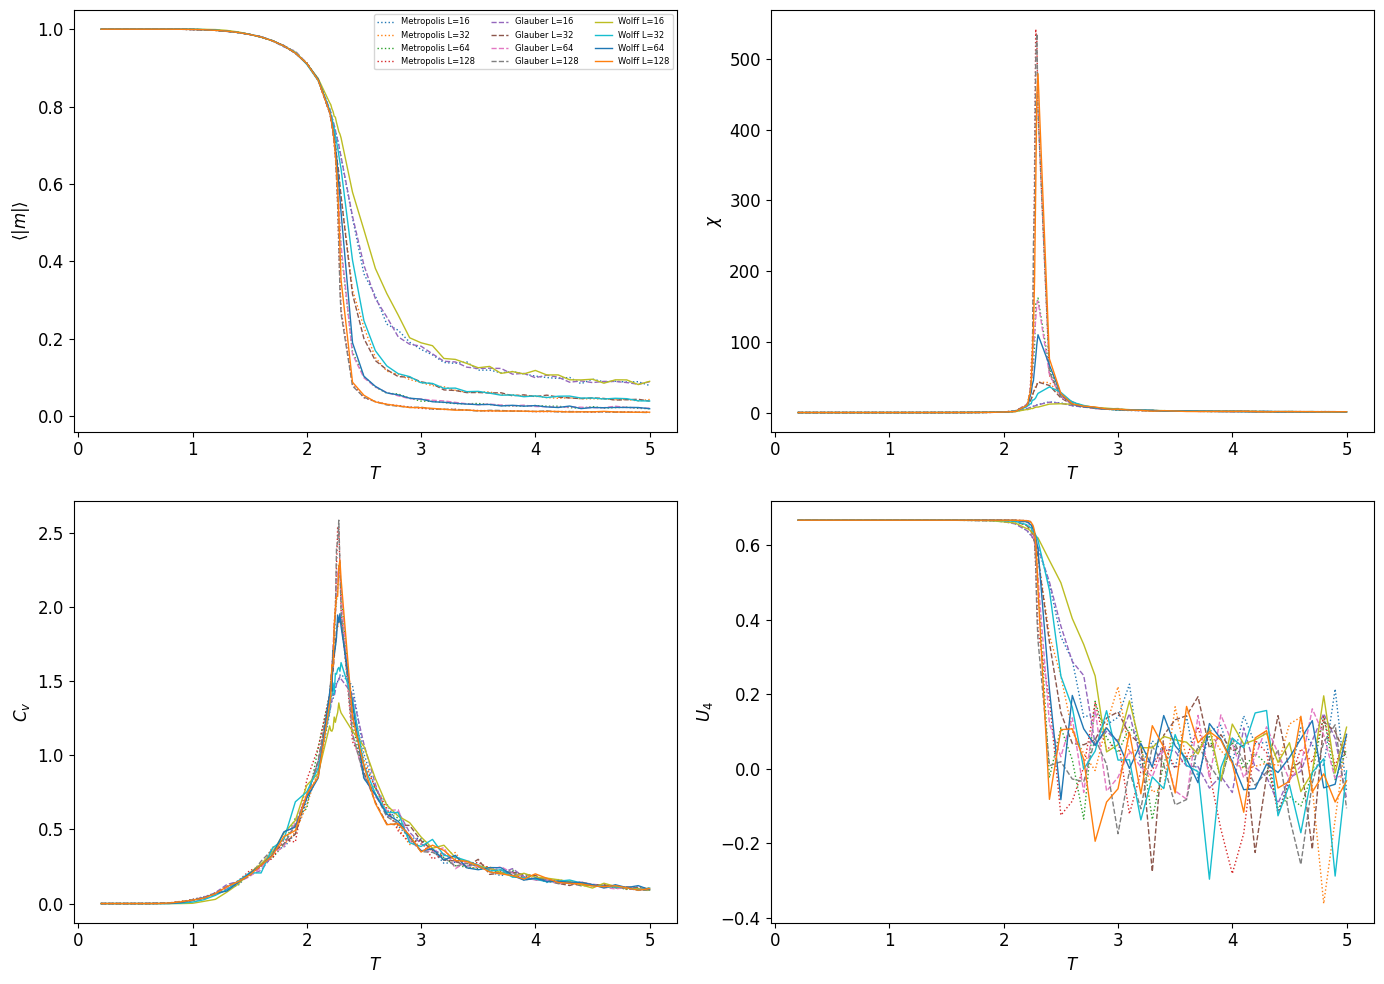

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
observables = [
    ('m',   r'$\langle |m| \rangle$'),
    ('chi', r'$\chi$'),
    ('Cv',  r'$C_v$'),
    ('U4',  r'$U_4$'),
]
estilos = {'Wolff': '-', 'Glauber': '--', 'Metropolis': ':'}

for ax, (col, ylabel) in zip(axes.flat, observables):
    for algo, df in data.items():
        for L in L_values:
            s = df[df['L'] == L].sort_values('T')
            label = f'{algo} L={L}' if col == 'm' else None
            ax.plot(s['T'], s[col], estilos[algo], ms=2, lw=1, label=label)
    ax.set_xlabel(r'$T$')
    ax.set_ylabel(ylabel)

axes[0, 0].legend(fontsize=6, ncol=3)
plt.tight_layout()
plt.show()

## 5. Cumulante de Binder $U_4$

Un panel por algoritmo mostrando $U_4(T)$ para cada $L$, con la línea vertical en $T_c$. El cruce de las curvas para distintos $L$ señala la temperatura crítica.

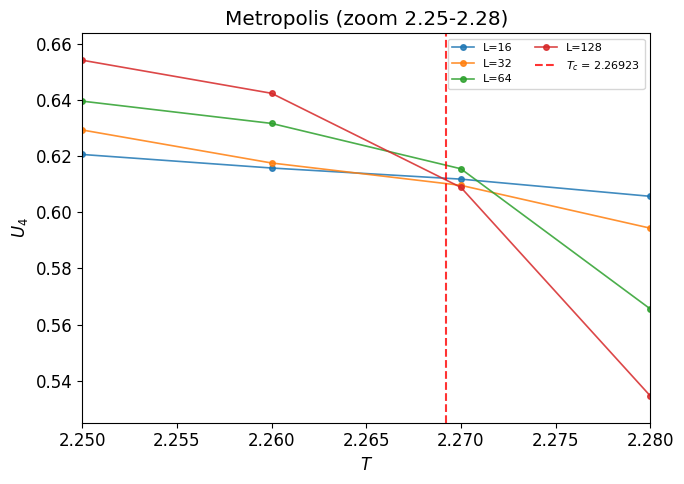

In [5]:
# Zoom fuerte del Binder cerca de Tc (Metropolis)
T_zoom_min, T_zoom_max = 2.25, 2.28
algo_target = 'Metropolis'

df = data[algo_target]
Tc = results.loc[algo_target, 'Tc']
y_min, y_max = np.inf, -np.inf

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for L in L_values:
    s = df[df['L'] == L].sort_values('T').copy()
    sz = s[(s['T'] >= T_zoom_min) & (s['T'] <= T_zoom_max)]
    if len(sz) == 0:
        continue

    ax.plot(sz['T'], sz['U4'], '-o', ms=4, lw=1.2, alpha=0.85, label=f'L={L}')
    y_min = min(y_min, sz['U4'].min())
    y_max = max(y_max, sz['U4'].max())

ax.axvline(Tc, color='red', ls='--', alpha=0.8, label=f'$T_c$ = {Tc:.5f}')
ax.set_xlim(T_zoom_min, T_zoom_max)
if np.isfinite(y_min) and np.isfinite(y_max):
    margin = 0.08 * (y_max - y_min if y_max > y_min else 0.02)
    ax.set_ylim(y_min - margin, y_max + margin)

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$U_4$')
ax.set_title(f'{algo_target} (zoom 2.25-2.28)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

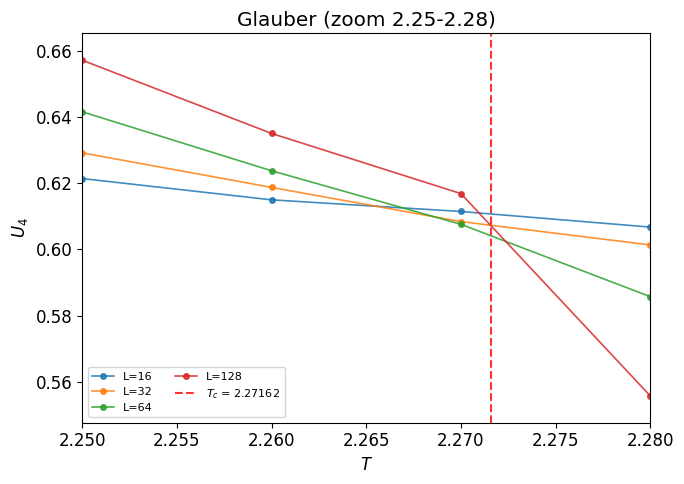

In [6]:
# Zoom fuerte del Binder cerca de Tc (Glauber)
T_zoom_min, T_zoom_max = 2.25, 2.28
algo_target = 'Glauber'

df = data[algo_target]
Tc = results.loc[algo_target, 'Tc']
y_min, y_max = np.inf, -np.inf

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for L in L_values:
    s = df[df['L'] == L].sort_values('T').copy()
    sz = s[(s['T'] >= T_zoom_min) & (s['T'] <= T_zoom_max)]
    if len(sz) == 0:
        continue

    ax.plot(sz['T'], sz['U4'], '-o', ms=4, lw=1.2, alpha=0.85, label=f'L={L}')
    y_min = min(y_min, sz['U4'].min())
    y_max = max(y_max, sz['U4'].max())

ax.axvline(Tc, color='red', ls='--', alpha=0.8, label=f'$T_c$ = {Tc:.5f}')
ax.set_xlim(T_zoom_min, T_zoom_max)
if np.isfinite(y_min) and np.isfinite(y_max):
    margin = 0.08 * (y_max - y_min if y_max > y_min else 0.02)
    ax.set_ylim(y_min - margin, y_max + margin)

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$U_4$')
ax.set_title(f'{algo_target} (zoom 2.25-2.28)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

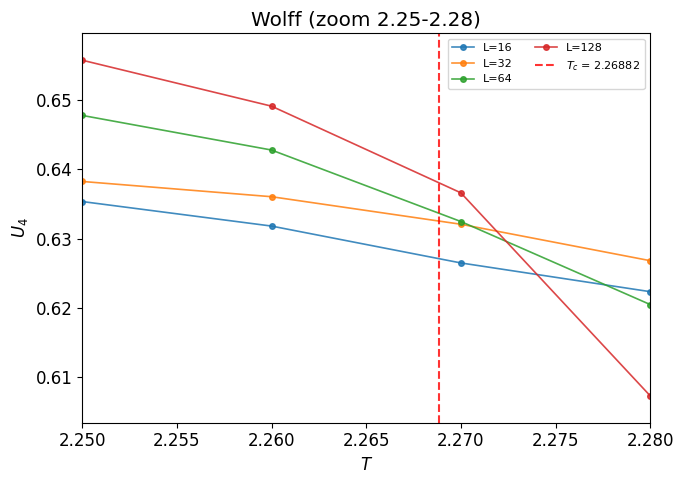

In [7]:
# Zoom fuerte del Binder cerca de Tc (Wolff)
T_zoom_min, T_zoom_max = 2.25, 2.28
algo_target = 'Wolff'

df = data[algo_target]
Tc = results.loc[algo_target, 'Tc']
y_min, y_max = np.inf, -np.inf

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for L in L_values:
    s = df[df['L'] == L].sort_values('T').copy()
    sz = s[(s['T'] >= T_zoom_min) & (s['T'] <= T_zoom_max)]
    if len(sz) == 0:
        continue

    ax.plot(sz['T'], sz['U4'], '-o', ms=4, lw=1.2, alpha=0.85, label=f'L={L}')
    y_min = min(y_min, sz['U4'].min())
    y_max = max(y_max, sz['U4'].max())

ax.axvline(Tc, color='red', ls='--', alpha=0.8, label=f'$T_c$ = {Tc:.5f}')
ax.set_xlim(T_zoom_min, T_zoom_max)
if np.isfinite(y_min) and np.isfinite(y_max):
    margin = 0.08 * (y_max - y_min if y_max > y_min else 0.02)
    ax.set_ylim(y_min - margin, y_max + margin)

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$U_4$')
ax.set_title(f'{algo_target} (zoom 2.25-2.28)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Tc por interpolación polinómica de cruces (U4):


,Tc_guess,Tc_poly_extrap,delta_vs_guess
algoritmo,,,
Metropolis,2.269226,2.261331,-0.007895
Glauber,2.271616,2.260719,-0.010898
Wolff,2.268818,2.261651,-0.007167


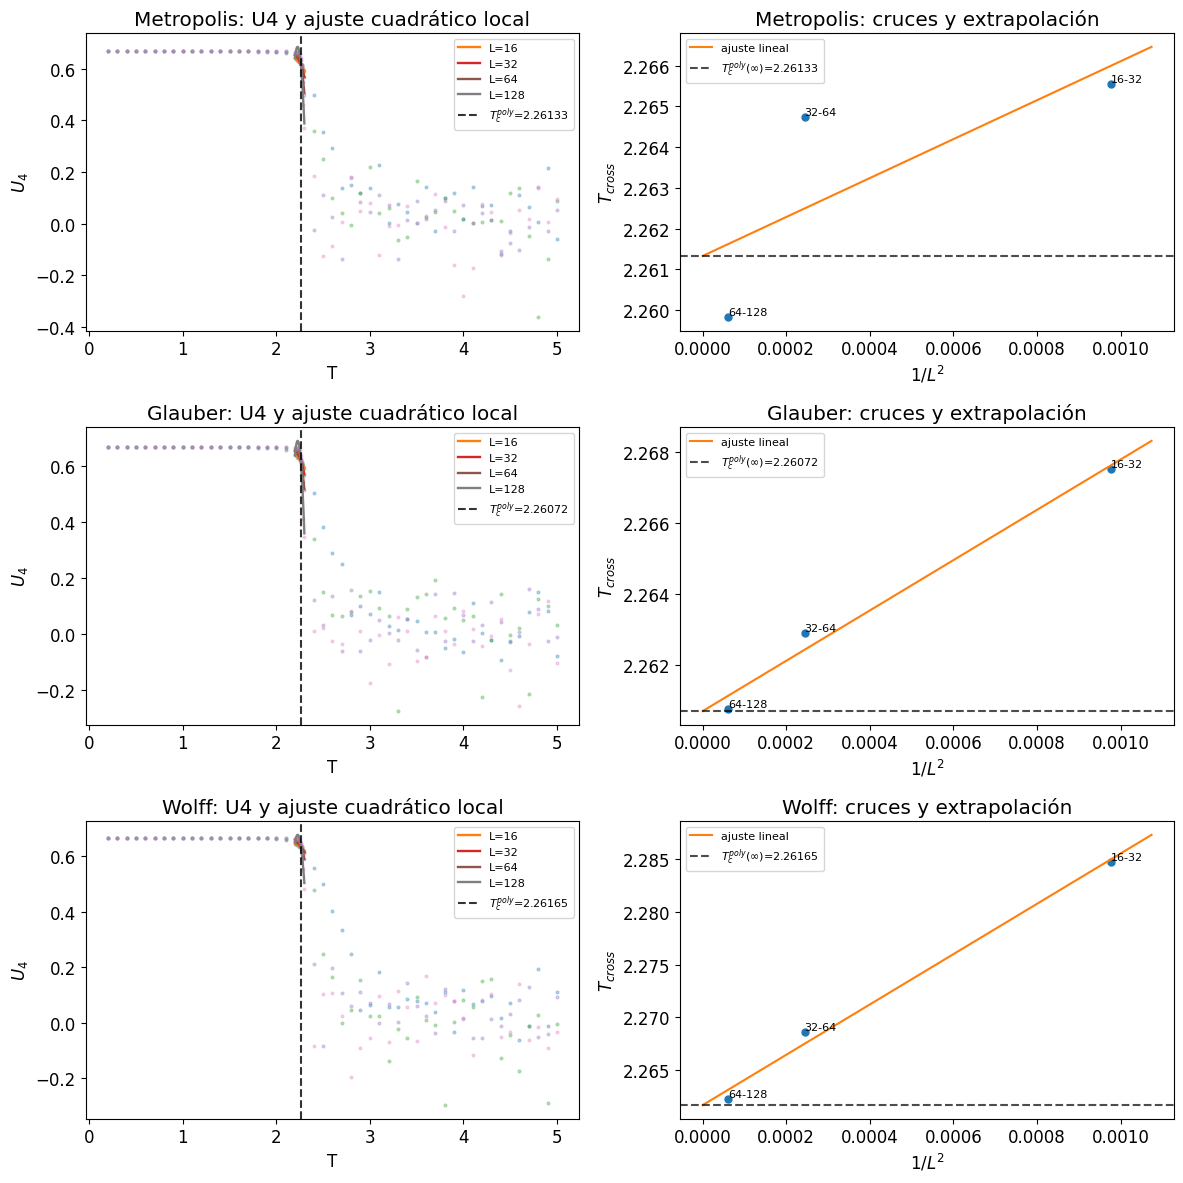

In [8]:
# 6. Interpolación polinómica (cuadrática) del cumulante de Binder
#    y extrapolación de Tc con cruces entre tamaños consecutivos

import warnings


def _fit_quadratic_near_tc(df_algo, L, tc_guess, window=0.12, min_pts=5):
    s = df_algo[df_algo['L'] == L].sort_values('T')[['T', 'U4']].copy()
    sw = s[(s['T'] >= tc_guess - window) & (s['T'] <= tc_guess + window)]

    if len(sw) < min_pts:
        s = s.assign(dist=np.abs(s['T'] - tc_guess)).sort_values('dist')
        sw = s.head(min_pts).sort_values('T')[['T', 'U4']]

    if len(sw) < 3:
        return None, None

    coeff = np.polyfit(sw['T'].values, sw['U4'].values, deg=2)
    poly = np.poly1d(coeff)
    return poly, sw


def _select_crossing_root(poly_diff, tc_guess, tmin, tmax):
    roots = np.roots(poly_diff)
    real_roots = np.real(roots[np.isreal(roots)])
    real_roots = real_roots[(real_roots >= tmin) & (real_roots <= tmax)]
    if len(real_roots) == 0:
        return np.nan
    return real_roots[np.argmin((real_roots - tc_guess) ** 2)]


poly_cross_summary = []

for algo, df in data.items():
    tc_guess = float(results.loc[algo, 'Tc']) if 'results' in globals() else float(df['T'].median())

    # Ajuste cuadrático U4(T) para cada tamaño L, cerca de Tc
    fitted = {}
    fitted_windows = {}
    for L in L_values:
        poly, sw = _fit_quadratic_near_tc(df, L, tc_guess=tc_guess, window=0.12, min_pts=5)
        fitted[L] = poly
        fitted_windows[L] = sw

    # Cruces entre pares consecutivos de tamaños
    crossings = []
    x_invL2 = []
    pair_labels = []

    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        if fitted[L1] is None or fitted[L2] is None:
            crossings.append(np.nan)
            x_invL2.append(1.0 / (L2 ** 2))
            pair_labels.append(f'{L1}-{L2}')
            continue

        s1 = df[df['L'] == L1]
        s2 = df[df['L'] == L2]
        tmin = max(s1['T'].min(), s2['T'].min())
        tmax = min(s1['T'].max(), s2['T'].max())

        poly_diff = np.poly1d(fitted[L2]) - np.poly1d(fitted[L1])
        tc_cross = _select_crossing_root(poly_diff, tc_guess=tc_guess, tmin=tmin, tmax=tmax)

        crossings.append(tc_cross)
        x_invL2.append(1.0 / (L2 ** 2))
        pair_labels.append(f'{L1}-{L2}')

    crossings = np.array(crossings, dtype=float)
    x_invL2 = np.array(x_invL2, dtype=float)
    valid = np.isfinite(crossings)

    if valid.sum() >= 2:
        # Tc(inf) = intercepto del ajuste lineal crossing vs 1/L^2
        p = np.polyfit(x_invL2[valid], crossings[valid], deg=1)
        slope, tc_inf = p[0], p[1]
    elif valid.sum() == 1:
        slope, tc_inf = np.nan, crossings[valid][0]
        warnings.warn(f'{algo}: solo hay un cruce válido; no se puede extrapolar linealmente.')
    else:
        slope, tc_inf = np.nan, np.nan
        warnings.warn(f'{algo}: no se encontraron cruces válidos.')

    poly_cross_summary.append({
        'algoritmo': algo,
        'Tc_guess': tc_guess,
        'Tc_poly_extrap': tc_inf,
        'slope_vs_1_over_L2': slope,
        'pairs': pair_labels,
        'crossings': crossings,
        'x_invL2': x_invL2,
        'fitted': fitted,
        'windows': fitted_windows,
    })

# Tabla resumen
poly_results = pd.DataFrame([
    {
        'algoritmo': d['algoritmo'],
        'Tc_guess': d['Tc_guess'],
        'Tc_poly_extrap': d['Tc_poly_extrap'],
        'delta_vs_guess': d['Tc_poly_extrap'] - d['Tc_guess'] if np.isfinite(d['Tc_poly_extrap']) else np.nan,
    }
    for d in poly_cross_summary
]).set_index('algoritmo')

print('Tc por interpolación polinómica de cruces (U4):')
display(poly_results)

# Gráficas: (1) ajustes cuadráticos cerca de Tc, (2) extrapolación de cruces
fig, axes = plt.subplots(len(poly_cross_summary), 2, figsize=(12, 4 * len(poly_cross_summary)))
if len(poly_cross_summary) == 1:
    axes = np.array([axes])

for row, d in enumerate(poly_cross_summary):
    algo = d['algoritmo']
    ax1, ax2 = axes[row, 0], axes[row, 1]

    # Panel izquierdo: U4(T) + ajuste cuadrático por L
    for L in L_values:
        s = data[algo][data[algo]['L'] == L].sort_values('T')
        ax1.plot(s['T'], s['U4'], 'o', ms=2, alpha=0.3)

        poly = d['fitted'][L]
        sw = d['windows'][L]
        if poly is not None and sw is not None and len(sw) >= 3:
            tgrid = np.linspace(sw['T'].min(), sw['T'].max(), 200)
            ax1.plot(tgrid, poly(tgrid), lw=1.7, label=f'L={L}')

    if np.isfinite(d['Tc_poly_extrap']):
        ax1.axvline(d['Tc_poly_extrap'], color='k', ls='--', alpha=0.8,
                    label=f"$T_c^{{poly}}$={d['Tc_poly_extrap']:.5f}")

    ax1.set_title(f'{algo}: U4 y ajuste cuadrático local')
    ax1.set_xlabel('T')
    ax1.set_ylabel(r'$U_4$')
    ax1.legend(fontsize=8)

    # Panel derecho: cruces vs 1/L^2
    x = d['x_invL2']
    y = d['crossings']
    valid = np.isfinite(y)

    ax2.plot(x[valid], y[valid], 'o', ms=5)
    for xv, yv, lbl in zip(x[valid], y[valid], np.array(d['pairs'])[valid]):
        ax2.text(xv, yv, lbl, fontsize=8, ha='left', va='bottom')

    if valid.sum() >= 2 and np.isfinite(d['slope_vs_1_over_L2']) and np.isfinite(d['Tc_poly_extrap']):
        xx = np.linspace(0, max(x) * 1.1, 200)
        yy = d['Tc_poly_extrap'] + d['slope_vs_1_over_L2'] * xx
        ax2.plot(xx, yy, '-', lw=1.5, label='ajuste lineal')
        ax2.axhline(d['Tc_poly_extrap'], color='k', ls='--', alpha=0.7,
                    label=f"$T_c^{{poly}}(\infty)$={d['Tc_poly_extrap']:.5f}")

    ax2.set_title(f'{algo}: cruces y extrapolación')
    ax2.set_xlabel(r'$1/L^2$')
    ax2.set_ylabel(r'$T_{cross}$')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

def plot_fss_collapse_chi_metropolis(Tc, nu, gamma):
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"FSS Collapse | Susceptibility | Metropolis\n$T_c$ = {Tc:.4f}, $\\nu$ = {nu:.3f}, $\\gamma$ = {gamma:.3f}", fontsize=12)
    algo = 'Metropolis'
    
    df = data[algo]
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        T_vals = s['T'].values
        
        x = (T_vals - Tc) * (L**(1.0 / nu))
        y = s['chi'].values * (L**(-gamma / nu))
            
        # Plot only points
        ax.plot(x, y, 'o', markersize=5, alpha=0.7, label=f'L={L}')
        
    ax.set_xlabel(r'$(T - T_c) L^{1/\nu}$')
    ax.set_ylabel(r'$\chi L^{-\gamma/\nu}$')
    ax.set_xlim(-2, 6)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive sliders for Metropolis
widgets.interact(
    plot_fss_collapse_chi_metropolis,
    Tc=widgets.FloatSlider(value=2.269, min=2.24, max=2.30, step=0.001, description='$T_c$:', readout_format='.4f'),
    nu=widgets.FloatSlider(value=1.000, min=0.8, max=1.2, step=0.005, description='$\\nu$:', readout_format='.3f'),
    gamma=widgets.FloatSlider(value=1.750, min=1.5, max=2.0, step=0.005, description='$\\gamma$:', readout_format='.3f')
);

interactive(children=(FloatSlider(value=2.269, description='$T_c$:', max=2.3, min=2.24, readout_format='.4f', …

In [ ]:
def plot_fss_collapse_chi_glauber(Tc, nu, gamma):
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"FSS Collapse | Susceptibility | Glauber\n$T_c$ = {Tc:.4f}, $\\nu$ = {nu:.3f}, $\\gamma$ = {gamma:.3f}", fontsize=12)
    algo = 'Glauber'
    
    df = data[algo]
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        T_vals = s['T'].values
        
        x = (T_vals - Tc) * (L**(1.0 / nu))
        y = s['chi'].values * (L**(-gamma / nu))
            
        # Plot only points
        ax.plot(x, y, 'o', markersize=5, alpha=0.7, label=f'L={L}')
        
    ax.set_xlabel(r'$(T - T_c) L^{1/\nu}$')
    ax.set_ylabel(r'$\chi L^{-\gamma/\nu}$')
    ax.set_xlim(-2, 6)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive sliders for Glauber
widgets.interact(
    plot_fss_collapse_chi_glauber,
    Tc=widgets.FloatSlider(value=2.269, min=2.24, max=2.30, step=0.001, description='$T_c$:', readout_format='.4f'),
    nu=widgets.FloatSlider(value=1.000, min=0.8, max=1.2, step=0.005, description='$\\nu$:', readout_format='.3f'),
    gamma=widgets.FloatSlider(value=1.750, min=1.5, max=2.0, step=0.005, description='$\\gamma$:', readout_format='.3f')
);

interactive(children=(FloatSlider(value=2.269, description='$T_c$:', max=2.3, min=2.24, readout_format='.4f', …

In [22]:
def plot_fss_collapse_chi_wolff(Tc, nu, gamma):
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"FSS Collapse | Susceptibility | Wolff\n$T_c$ = {Tc:.4f}, $\\nu$ = {nu:.3f}, $\\gamma$ = {gamma:.3f}", fontsize=12)
    algo = 'Wolff'
    
    df = data[algo]
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        T_vals = s['T'].values
        
        x = (T_vals - Tc) * (L**(1.0 / nu))
        y = s['chi'].values * (L**(-gamma / nu))
            
        # Plot only points
        ax.plot(x, y, 'o', markersize=5, alpha=0.7, label=f'L={L}')
        
    ax.set_xlabel(r'$(T - T_c) L^{1/\nu}$')
    ax.set_ylabel(r'$\chi L^{-\gamma/\nu}$')
    ax.set_xlim(-4, 10)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive sliders for Wolff
widgets.interact(
    plot_fss_collapse_chi_wolff,
    Tc=widgets.FloatSlider(value=2.269, min=2.24, max=2.30, step=0.001, description='$T_c$:', readout_format='.4f'),
    nu=widgets.FloatSlider(value=1.000, min=0.8, max=1.2, step=0.005, description='$\\nu$:', readout_format='.3f'),
    gamma=widgets.FloatSlider(value=1.750, min=1.5, max=2.0, step=0.005, description='$\\gamma$:', readout_format='.3f')
);

interactive(children=(FloatSlider(value=2.269, description='$T_c$:', max=2.3, min=2.24, readout_format='.4f', …